In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# dane syntetyczne
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# ++ bias
X_b = np.c_[np.ones((100, 1)), X]

# inicjalizacja parametrów
theta = np.random.randn(2, 1)

# parametry dla GD
eta = 0.1
n_iterations = 1000
m = len(X)

# gradient descent
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T @ (X_b @ theta - y)
    theta -= eta * gradients

print("Współczynniki regresji:", theta)

Współczynniki regresji: [[4.21509616]
 [2.77011339]]


In [3]:
# funckja test
def f(w):
    return (w - 3)**2

def grad_f(w):
    return 2*(w - 3)

# optymalizatory
def optimizer(name, lr=0.1, n_iter=50):
    w = 0
    history = [w]
    v, s = 0, 0
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8

    for t in range(1, n_iter+1):
        g = grad_f(w)

        if name == 'gd':
            w -= lr * g

        elif name == 'momentum':
            v = beta1 * v + lr * g
            w -= v

        elif name == 'rmsprop':
            s = beta2 * s + (1 - beta2) * g**2
            w -= lr / (np.sqrt(s) + eps) * g

        elif name == 'adam':
            v = beta1 * v + (1 - beta1) * g
            s = beta2 * s + (1 - beta2) * g**2
            v_corr = v / (1 - beta1**t)
            s_corr = s / (1 - beta2**t)
            w -= lr * v_corr / (np.sqrt(s_corr) + eps)

        history.append(w)

    return history

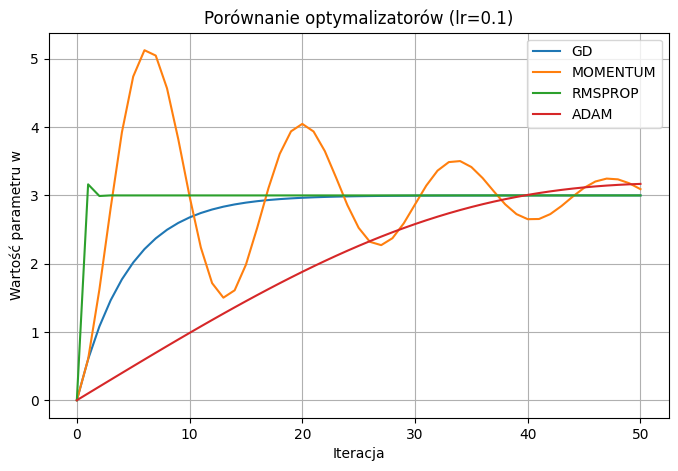

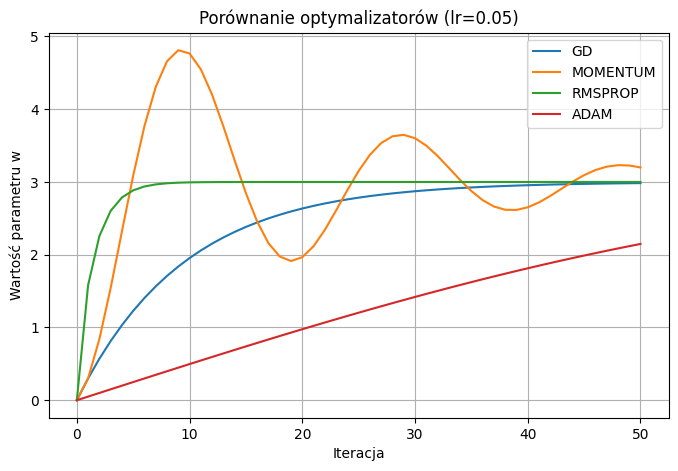

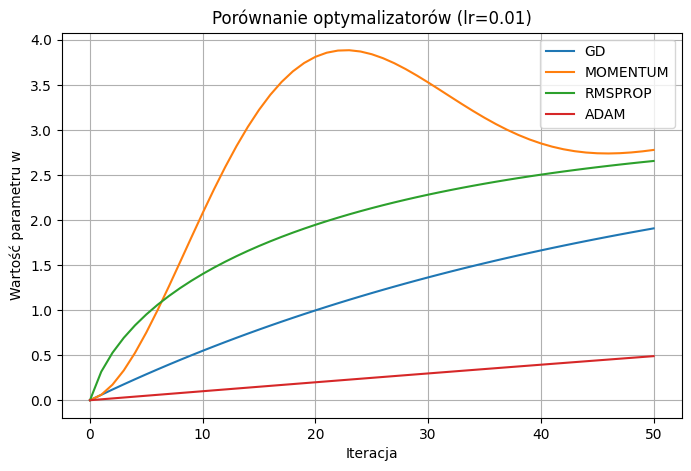

In [4]:
learning_rates = [0.1, 0.05, 0.01]
optimizers = ['gd', 'momentum', 'rmsprop', 'adam']

for lr in learning_rates:
    plt.figure(figsize=(8,5))
    
    for opt in optimizers:
        history = optimizer(opt, lr=lr)
        plt.plot(history, label=opt.upper())
    
    plt.title(f"Porównanie optymalizatorów (lr={lr})")
    plt.xlabel("Iteracja")
    plt.ylabel("Wartość parametru w")
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
# wariant 9 z zadania : f(x, y) = (x^2 - y^2) / (1 + x^2 + y^2)

def f_xy(x, y):
    return (x**2 - y**2) / (1 + x**2 + y**2)

def grad_f_xy(x, y):
    denom = (1 + x**2 + y**2)**2
    
    dx = (2*x*(1 + x**2 + y**2) - (x**2 - y**2)*2*x) / denom
    dy = (-2*y*(1 + x**2 + y**2) - (x**2 - y**2)*2*y) / denom
    
    return np.array([dx, dy])

In [6]:
def optimize_path(opt_name, lr=0.01, steps=200):
    pos = np.array([1.5, 1.5])
    path = [pos.copy()]
    
    v = np.zeros(2)
    s = np.zeros(2)
    
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8

    for t in range(1, steps+1):
        grad = grad_f_xy(*pos)

        if opt_name == 'gd':
            pos -= lr * grad

        elif opt_name == 'momentum':
            v = beta1 * v + lr * grad
            pos -= v

        elif opt_name == 'rmsprop':
            s = beta2 * s + (1 - beta2) * grad**2
            pos -= lr / (np.sqrt(s) + eps) * grad

        elif opt_name == 'adam':
            v = beta1 * v + (1 - beta1) * grad
            s = beta2 * s + (1 - beta2) * grad**2
            v_corr = v / (1 - beta1**t)
            s_corr = s / (1 - beta2**t)
            pos -= lr * v_corr / (np.sqrt(s_corr) + eps)

        path.append(pos.copy())

    return np.array(path)

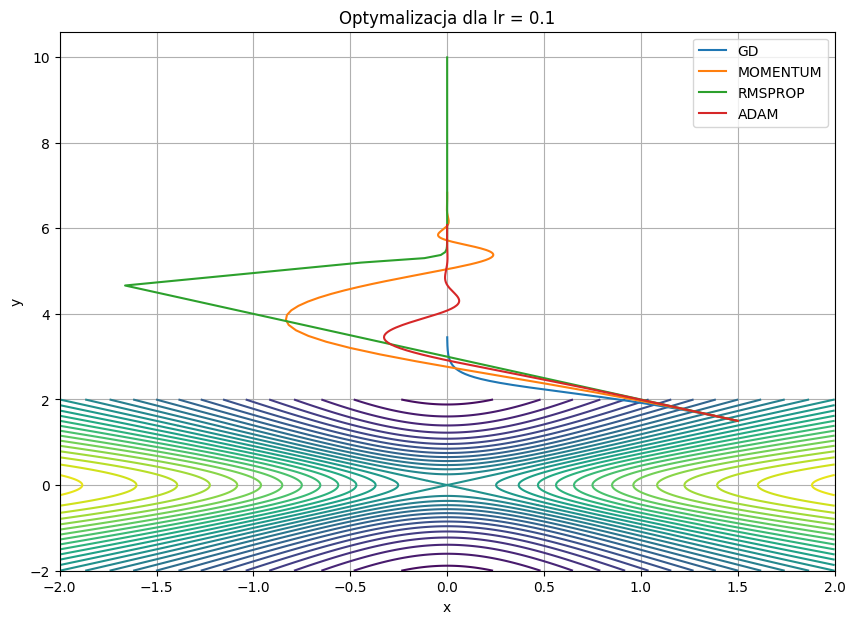

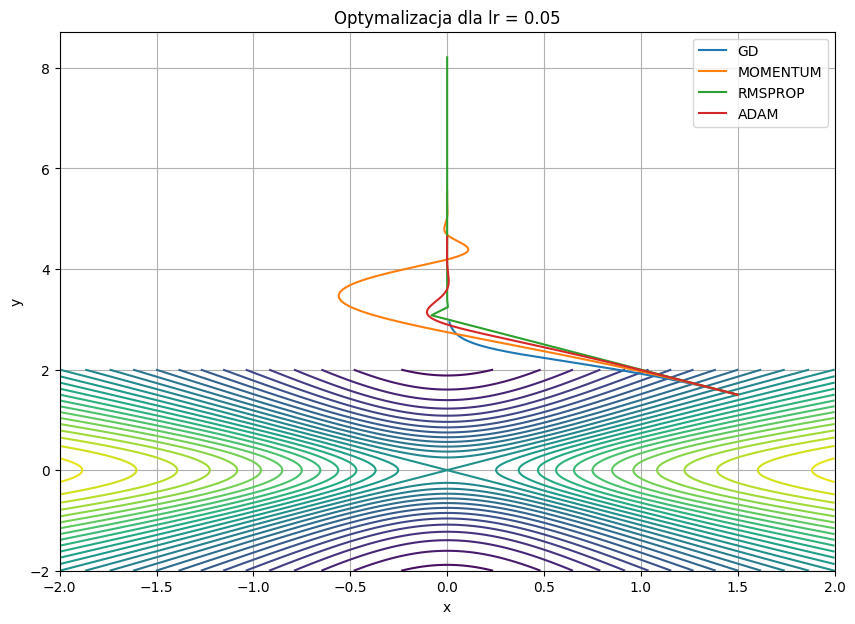

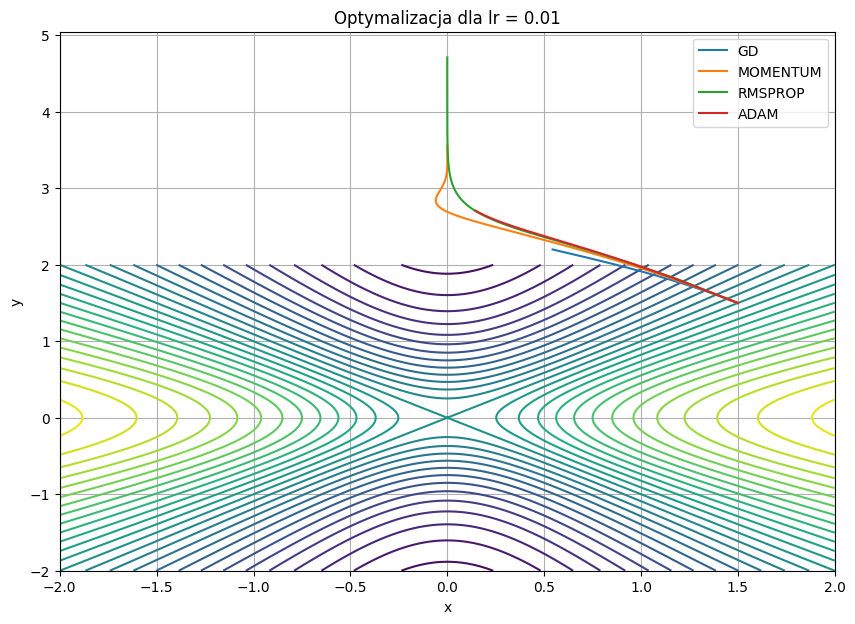

In [7]:
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = f_xy(X, Y)

learning_rates = [0.1, 0.05, 0.01]
optimizers = ['gd', 'momentum', 'rmsprop', 'adam']

for lr in learning_rates:
    plt.figure(figsize=(10, 7))
    plt.contour(X, Y, Z, levels=30)

    for opt in optimizers:
        path = optimize_path(opt, lr=lr)
        plt.plot(path[:,0], path[:,1], label=opt.upper())

    plt.title(f"Optymalizacja dla lr = {lr}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import datetime

In [9]:
# zbior MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# reshape
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# wariant bez normalizacji
x_train_raw = x_train.copy()
x_test_raw = x_test.copy()

# wariant z normalizacja
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [10]:
def create_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [11]:
# timestamp w logach
log_dir_raw = "logs/raw/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir_norm = "logs/norm/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# callbacki
tb_raw = tf.keras.callbacks.TensorBoard(log_dir=log_dir_raw, histogram_freq=1)
tb_norm = tf.keras.callbacks.TensorBoard(log_dir=log_dir_norm, histogram_freq=1)

# model bez normalizacji
model_raw = create_model()
history_raw = model_raw.fit(
    x_train_raw, y_train,
    epochs=5,
    validation_data=(x_test_raw, y_test),
    callbacks=[tb_raw]
)

# z normalizacja
model_norm = create_model()
history_norm = model_norm.fit(
    x_train_norm, y_train,
    epochs=5,
    validation_data=(x_test_norm, y_test),
    callbacks=[tb_norm]
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8596 - loss: 2.6836 - val_accuracy: 0.8921 - val_loss: 0.4878
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9114 - loss: 0.3863 - val_accuracy: 0.9166 - val_loss: 0.3153
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9301 - loss: 0.2861 - val_accuracy: 0.9288 - val_loss: 0.3140
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9370 - loss: 0.2565 - val_accuracy: 0.9340 - val_loss: 0.3095
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9436 - loss: 0.2309 - val_accuracy: 0.9386 - val_loss: 0.2597
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9240 - loss: 0.2623 - val_accuracy: 0.9567 - val_loss: 0.1513
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9660 - loss: 0.1154 - val_accuracy: 0.9701 - val_loss: 0.1034
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9763 - loss: 0.0780 - v

In [12]:
%load_ext tensorboard

In [13]:
%tensorboard --logdir logs